# Receiving robot state

In this notebook, we will demonstrate how to receive and process state messages from the UR3e mockup. The mockup publishes its state messages with the `robotarm.state` routing key:
- `ROBOT_MODE`: Current mode of the robot (e.g., RUNNING, Idle).
- `Q_ACTUAL`: Current joint positions (radians).
- `QD_ACTUAL`: Current joint velocities (radians/second).
- `Q_TARGET`: Target joint positions (radians).
- `TIMESTAMP`: Timestamp of the status message.
- `JOINT_MAX_SPEED`: Maximum joint speeds (radians/second).
- `JOINT_MAX_ACCELERATION`: Maximum joint accelerations (radians/second²).
- `TCP_POSE`: Current TCP pose (position and orientation).

To receive these messages, we will set up a RabbitMQ consumer that listens for messages with the `robotarm.state` routing key. Below is an example of how to implement this in Python using the communication module provided in the project.

> Make sure the credentials match those from your RabbitMQ server setup.

In [15]:
from communication import protocol
from communication.rabbitmq import Rabbitmq

try:
    rmq = Rabbitmq(
        ip="localhost",
        port=5672,
        username="ur3e",
        password="ur3e",
        vhost="/",
        exchange="UR3E_AMQP",
        type="topic",
    )
    rmq.connect_to_server()
    print("✓ Connected to RabbitMQ successfully")
except Exception as e:
    print(f"✗ Failed to connect to RabbitMQ: {e}")
    print("\nMake sure RabbitMQ is running. You can start it with:")
    print("  python -m startup.start_docker_rabbitmq")

# define a callback function to handle received messages
def on_message_received(ch, method, properties, body):
    try:
        print("✓ State:")
        print(body)
    except Exception as e:
        print(f"✗ Failed to decode the message: {e}")

✓ Connected to RabbitMQ successfully


Running the next cell will set up the subscription and start receiving state messages from the mockup. Note that this will block the notebook until interrupted, which is in

In [16]:
# rmq.subscribe(
#     routing_key=protocol.ROUTING_KEY_STATE,
#     on_message_callback=on_message_received,
# )

# rmq.start_consuming()

In [17]:
q_values_record = []

def on_message_received2(ch, method, properties, body):
    try:
        print("✓ State:")
        print(body)
        q_values_record.append(body["q_actual"])
    except Exception as e:
        print(f"✗ Failed to decode the message: {e}")

rmq.subscribe(
    routing_key=protocol.ROUTING_KEY_STATE,
    on_message_callback=on_message_received2,
)

rmq.start_consuming()

✓ State:
{'robot_mode': 'Idle', 'q_actual': [-9.366049187810299e-07, -8.282356028762172e-07, -1.3007963643057501e-06, 7.851567262670992e-08, -8.09078852253042e-08, 8.337108347322992e-08], 'qd_actual': [0.0, 0.0, 5.684341886080802e-14, 5.684341886080802e-14, 0.0, 0.0], 'q_target': [3.552713678800501e-15, -8.881784197001252e-15, 8.881784197001252e-15, 1.2434497875801753e-14, -3.552713678800501e-15, 7.105427357601002e-15], 'timestamp': 4865.500000008935, 'joint_max_speed': 60, 'joint_max_acceleration': 80, 'tcp_pose': [-0.456756251581189, -0.22314445290836232, 0.06649599090926916, -1.967145211081879e-06, -8.556970335558957e-07, 1.5707963267950624]}
✓ State:
{'robot_mode': 'Idle', 'q_actual': [-1.0381159528633952e-06, -7.734123745778036e-07, -1.2905228146883173e-06, 1.1350220762829412e-08, -2.746670443993507e-09, -6.08308881638485e-08], 'qd_actual': [0.0, 0.0, 5.684341886080802e-14, 5.684341886080802e-14, 0.0, 0.0], 'q_target': [3.552713678800501e-15, -8.881784197001252e-15, 8.881784197001

KeyboardInterrupt: 

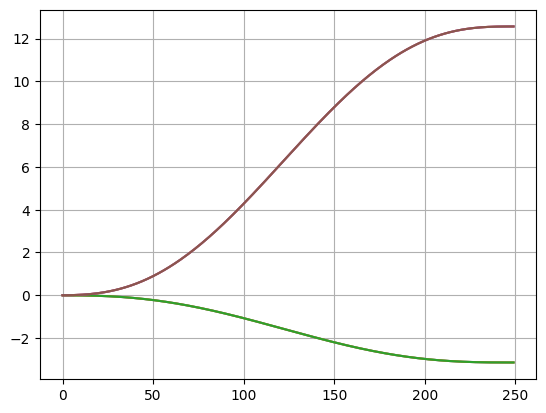

In [32]:
import matplotlib.pyplot as plt
import numpy as np

q_values_record = np.array(q_values_record)

plt.plot(q_values_record[44:294, :])
plt.grid()

In [28]:
v_r_s = (q_values_record[200, 3] - q_values_record[150, 3]) / (50 / 20) # x / t
v_rpi_s = v_r_s / np.pi
v_rpi_s

0.5697858270718387

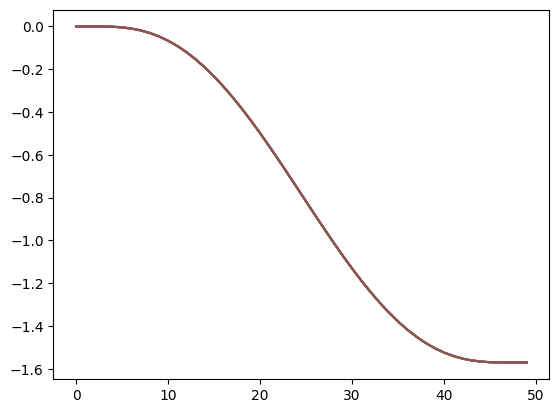

In [ ]:
plt.plot(q_values_record[350:400, :])

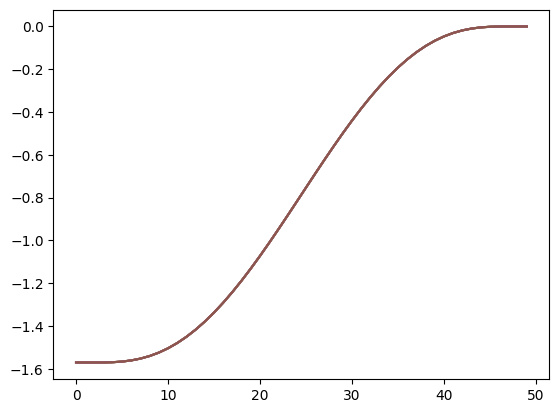

In [ ]:
plt.plot(q_values_record[530:580, :])

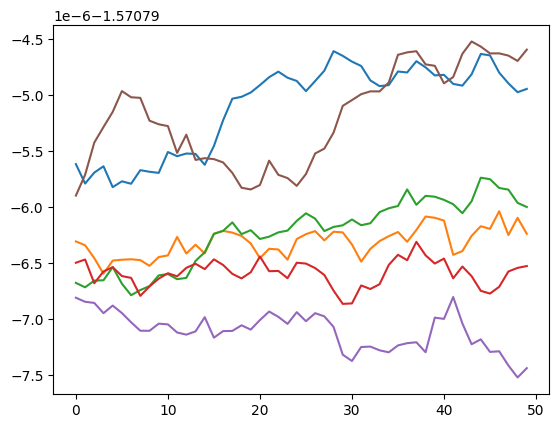

In [ ]:
plt.plot(q_values_record[300:350, :])

Try to modify the callback function to log the received state messages in a more structured format, such as a csv file. 

In [ ]:
rmq.close()